In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.impute import SimpleImputer

In [19]:
df = pd.read_csv("loan_data_set.csv")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [25]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [35]:
#Return the list of numeric indices &* fill in NaN values
numeric_cols = ["ApplicantIncome","CoapplicantIncome"]

si = SimpleImputer(strategy = 'median')
df[numeric_cols] = si.fit_transform(df[numeric_cols])

def remove_outliers(df, cols):
    for column in cols:
        if pd.api.types.is_numeric_dtype(df[column]):
            q1 = df[column].quantile(0.25)
            q3 = df[column].quantile(0.75)
            iqr = q3 - q1
            max_iqr = q3 + 1.5 * iqr
            min_iqr = q1 - 1.5 * iqr
            mask = (df[column] >= min_iqr) & (df[column] <= max_iqr)
            df = df[mask]
    return df
    
new_df = remove_outliers(df, numeric_cols)

new_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.0,360.0,1.0,Urban,Y


### Feature Transformations ###

A normal distribution of the data helps data scientists to solve the complex patterns of the data and gain valuable insights from the same, but in the algorithmic scenarios the distribution is not always desired according to distinctive datasets. Therefore, we need to implement a flexible yet comprehensive set that allows us to transform from one type to another one without doing it manually.


### Types of transformer ###
1. Function Transformers
2. Power Transformers
3. Quantile Transformers

____

### Function Transformers ###

Function transformers are the type of feature transformation technique that uses a particular function to transform the data to the normal distribution

- Log Transform: Right-skewed data
- Square Transform
- Square Root Transform: Left-skewed data
- Reciprocal Transform
- Custom Transforms

#### 1. Log Transformer ####

One of the most simplest, yet common technique in which the log is applied every single of distribution of the data and the result from  the log is considered the final day to feed the machine learning algorithms.

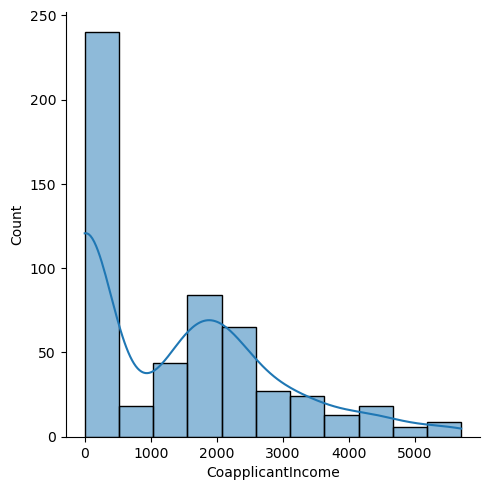

In [37]:
#The graph is right-skewed, thus we need to remove the "peak rises"

sns.displot(x = new_df["CoapplicantIncome"], kde = True)

In [54]:
from sklearn.preprocessing import FunctionTransformer

ft = FunctionTransformer(func = np.log1p)

new_df["CoapplicantIncome_ft"] = ft.fit_transform(new_df["CoapplicantIncome"])
data = ft.fit_transform(new_df["CoapplicantIncome"])

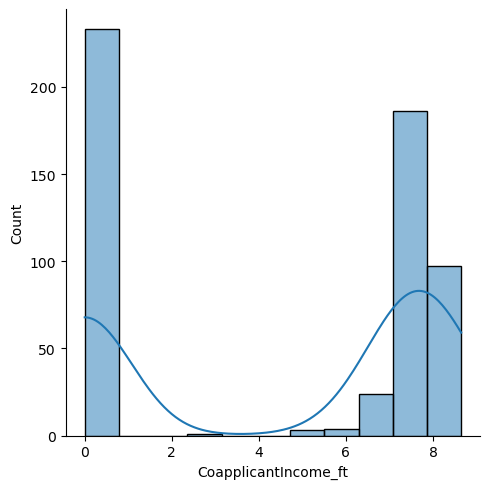

In [56]:
sns.displot(x = new_df["CoapplicantIncome_ft"], kde = True)
plt.show()

#### 2. Square Transformer ####

Square transform is the type of transformer in which the square of the data is considered instead of the normal data. In simple words, this transformed the data is applied with the square function, where the square of every single observation will be considered as the final transformed data.

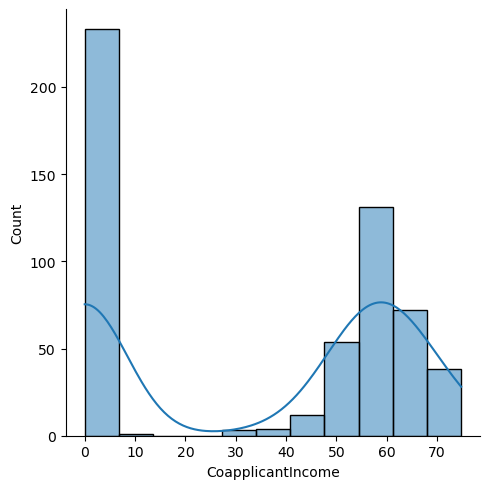

In [61]:
squared_data = np.square(data)
sns.displot(x = squared_data, kde = True)

#### 3. Square Root Transformer ####

In this transform, the square root of the data is calculated. This transform performs so well on the left-skewed data and efficiently transformed the left-skewed data into normally distributed data.

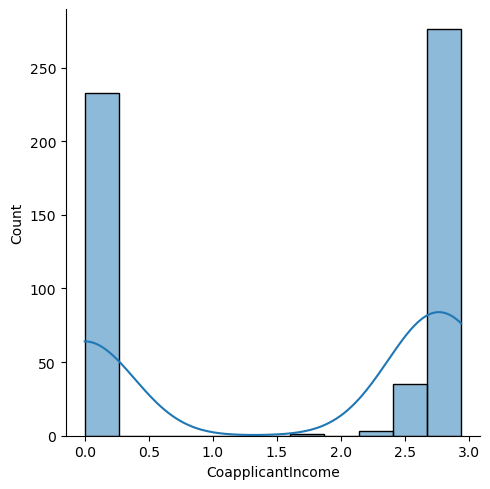

In [68]:
squared_data = np.sqrt(data)
sns.displot(x = squared_data, kde = True)

#### 4. Reciprocal Transformer ####

In this transformation, the reciprocal of every observation is considered. This transform is useful in some of the datasets as the reciprocal of the observations works well to achieve normal distributions.

C:\Users\Cresht\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in reciprocal
  result = getattr(ufunc, method)(*inputs, **kwargs)


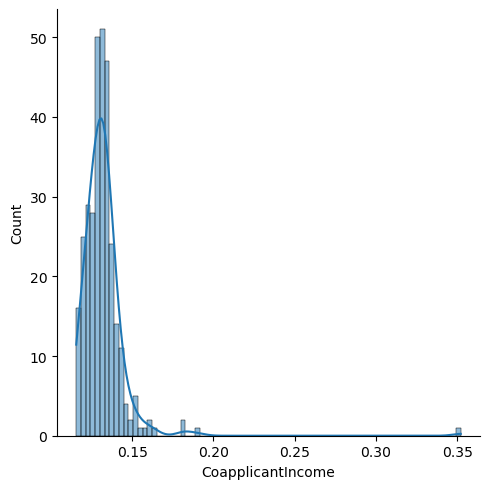

In [71]:
squared_data = np.reciprocal(data)
sns.displot(x = squared_data, kde = True)

#### 5. Custom Transformations ####

In every dataset, the log and square root transforms can not be used, as every data can have different patterns and complexity. Based on the domain knowledge of the data, custom transformations can be applied to transform the data into a normal distribution. The custom transforms here can be any function or parameter like sin, cos, tan, cube, etc.

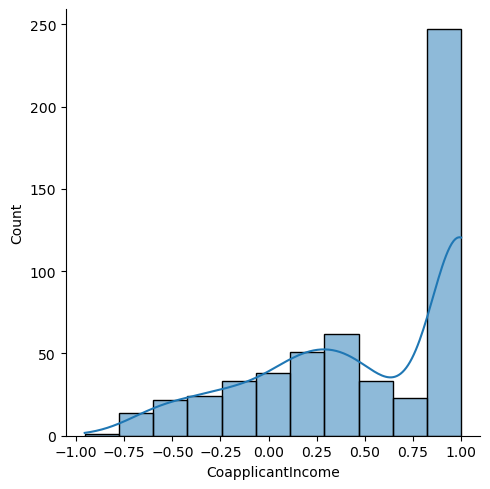

In [78]:
#squared_data = np.sin(data)
squared_data = np.cos(data)
#squared_data = np.tan(data)
sns.displot(x = squared_data, kde = True)

____

### Power Transformers ###

In [89]:
from sklearn.preprocessing import PowerTransformer

The type of power transformer techniques where the power is applied to the data observations for transforming data. There are two types of power transformers:

1. Box - Cox transformer
2. Yeo - Johnson transformer

#### 1. Box - Cox Transformer ####

The Box-Cox transformation is a technique used to stabilize the variance and make data well-distrubted (i.e Gaussian distribution) 

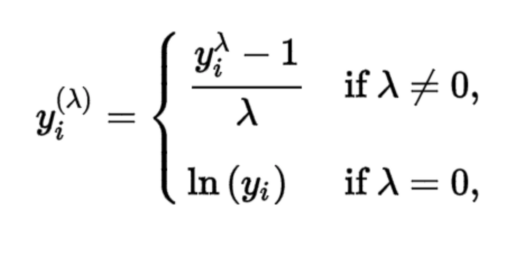

In [157]:
img = mpimg.imread("box-cox.png")
plt.imshow(img)
plt.axis("off")
plt.show()

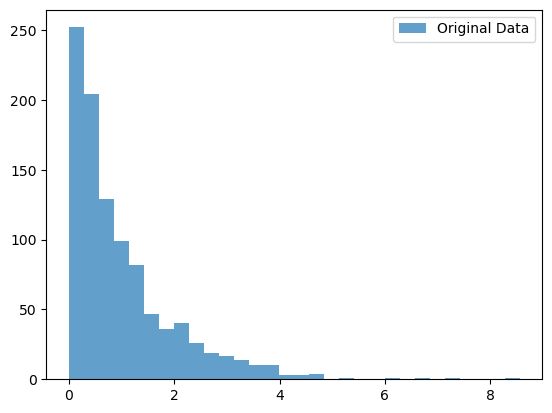

In [133]:
# Generating skewed data
np.random.seed(0)
data = np.random.exponential(size=1000).reshape(-1, 1)

# Visualizing the original data
plt.hist(data, bins=30, alpha=0.7, label='Original Data')
plt.legend()
plt.show()

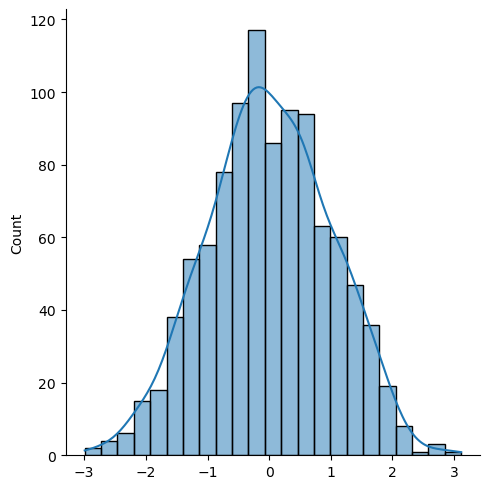

In [135]:
boxcox = PowerTransformer(method = "box-cox")
boxcox_data = boxcox.fit_transform(data)
sns.displot(x = boxcox_data.ravel(), kde = True)
plt.show()

#### 2. Yeo - Johnson Transformer ####

Similar to Box-Cox transformation, except it is an advanced form that also accepts zeros and non-positive numbers

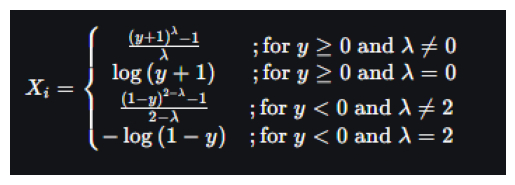

In [159]:
img = mpimg.imread("yeo-johnson.png")
plt.imshow(img)
plt.axis("off")
plt.show()

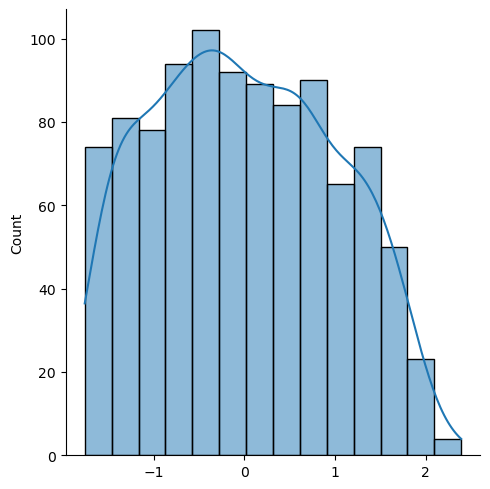

In [144]:
boxcox = PowerTransformer()
boxcox_data = boxcox.fit_transform(data)
sns.displot(x = boxcox_data.ravel(), kde = True)
plt.show()

____

### Quantile Transformer ###

Quantile transformation techniques are the type of feature transformation technique that can be applied to NY numerical data observations. This transformation technique can be implemented using sklearn.

In this transformation technique, the input data can be fed to this transformer where this transformer makes the distribution of the output data normal to fed to the further machine learning algorithm.

In [167]:
from sklearn.preprocessing import QuantileTransformer
quantile = QuantileTransformer(output_distribution='normal')
data_transformed = quantile.fit_transform(data)

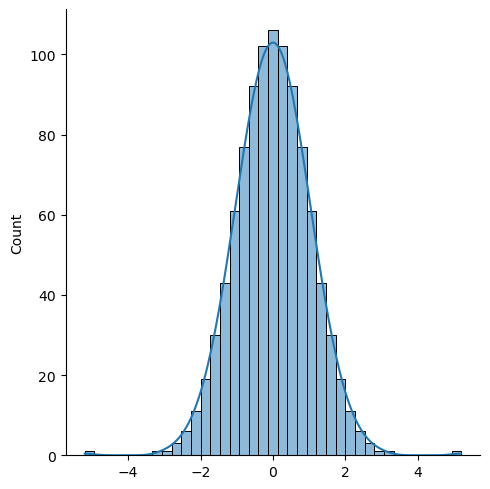

In [173]:
sns.displot(x = data_transformed.ravel(), kde = True)

### Key Takeaways ###

- The featured transformation techniques are used to transform the data to normal distribution for better performance of the algorithm.
- The Log transforms perform so well on the right-skewed data. Whereas the square root transformers perform so well on left-skewed data.
- Based on the domain knowledge of the problem statement and the data, the custom data transformations technique can be also applied efficiently.
- Box-Cox transformations can be applied to only positive data observations which return the transformed values between -5 to 5.
- Yeo Johnson's transformations technique can be applied to zero and negative values as well.